In [13]:
import numpy as np
import matplotlib.pyplot as plt
from Tools.data_utils import SimulationData, lorenz_stochastic
from Tools.mathematical_tools import mutual_information, false_nearest_neighbors

In [14]:
# Parametri
n_steps = 10000  # Numero di passi temporali
dt = 0.01        # Passo temporale
alpha = 0      # Intensità del rumore

# Simulazione
trajectory = lorenz_stochastic(n_steps, dt, alpha)
z1 = trajectory[:, 0]
z2 = trajectory[:, 1]
z3 = trajectory[:, 2]

In [15]:
# Inizializzazione della lista per salvare i risultati
range_f = 20  # Numero massimo di ritardi da analizzare
n_bins = 50   # Numero di bin per la discretizzazione
datDelayInformation_1 = []  
datDelayInformation_2 = []
datDelayInformation_3 = []

# Calcolo della mutual information per ogni ritardo
for delay in range(1, range_f):
    I = mutual_information(z1, delay, n_bins)  # mutual_information calcolata per z1
    datDelayInformation_1.append(I)

# Calcolo della mutual information per ogni ritardo
for delay in range(1, range_f):
    I = mutual_information(z2, delay, n_bins)  # mutual_information calcolata per z2
    datDelayInformation_2.append(I)

# Calcolo della mutual information per ogni ritardo
for delay in range(1, range_f):
    I = mutual_information(z3, delay, n_bins)  # mutual_information calcolata per z3
    datDelayInformation_3.append(I)

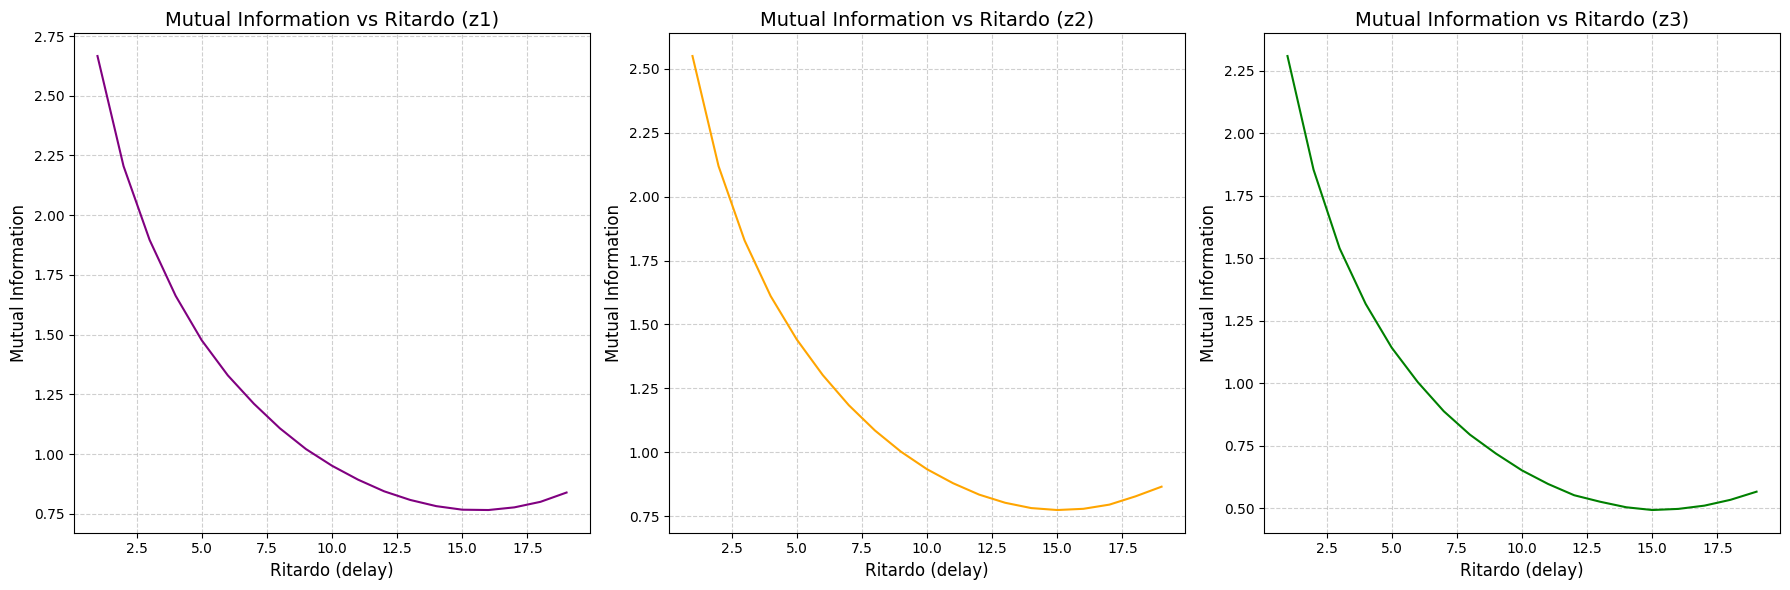

In [16]:
# Grafico dei risultati
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot for datDelayInformation_1
axs[0].plot(range(1, range_f), datDelayInformation_1, color='purple')
axs[0].set_xlabel('Ritardo (delay)', fontsize=12)
axs[0].set_ylabel('Mutual Information', fontsize=12)
axs[0].set_title('Mutual Information vs Ritardo (z1)', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot for datDelayInformation_2
axs[1].plot(range(1, range_f), datDelayInformation_2, color='orange')
axs[1].set_xlabel('Ritardo (delay)', fontsize=12)
axs[1].set_ylabel('Mutual Information', fontsize=12)
axs[1].set_title('Mutual Information vs Ritardo (z2)', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.6)

# Plot for datDelayInformation_3
axs[2].plot(range(1, range_f), datDelayInformation_3, color='green')
axs[2].set_xlabel('Ritardo (delay)', fontsize=12)
axs[2].set_ylabel('Mutual Information', fontsize=12)
axs[2].set_title('Mutual Information vs Ritardo (z3)', fontsize=14)
axs[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

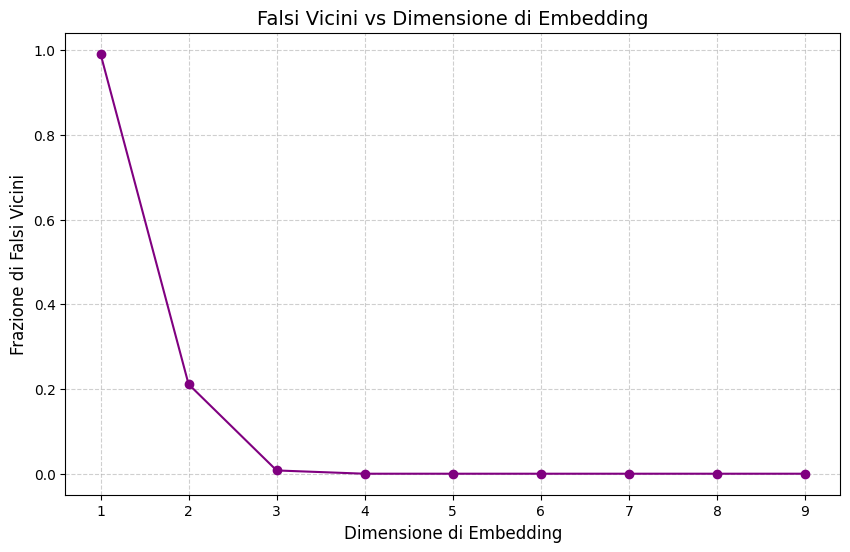

In [17]:
# Parametri
embedding_dimensions = range(1, 10)  # Dimensioni di embedding da analizzare
delay = 15  # Ritardo temporale
threshold = 10  # Soglia per definire i falsi vicini

# Esegui il calcolo della frazione di falsi vicini per i tuoi dati
false_neighbors_fractions = [
    false_nearest_neighbors(z2, delay, embedding_dimension=d, threshold=threshold)
    for d in embedding_dimensions
]

# Filtra eventuali valori None (se i dati sono insufficienti)
false_neighbors_fractions = [fnn for fnn in false_neighbors_fractions if fnn is not None]

# Grafico
plt.figure(figsize=(10, 6))
plt.plot(embedding_dimensions[:len(false_neighbors_fractions)], false_neighbors_fractions, marker='o', color='purple')
plt.xlabel('Dimensione di Embedding', fontsize=12)
plt.ylabel('Frazione di Falsi Vicini', fontsize=12)
plt.title('Falsi Vicini vs Dimensione di Embedding', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()